# 🚀 Spaceship Titanic — End-to-End Machine Learning Project

This project presents a complete end-to-end machine learning pipeline for predicting whether a passenger was transported to another dimension during the **Spaceship Titanic** incident. The primary objective was not only to achieve competitive predictive performance but also to build a clean, reproducible, and well-structured machine learning workflow.

The project begins with extensive exploratory data analysis (EDA) to understand the dataset and identify meaningful patterns. Instead of relying on simple global imputations, missing values were handled using relationships discovered during the analysis, resulting in an EDA-driven imputation strategy while carefully avoiding target leakage.

Several new features were engineered from the original dataset, including cabin decomposition, passenger group information, family identification, spending-related variables, and age-based indicators. These features were designed to provide the models with additional information beyond the raw dataset.

To ensure a consistent preprocessing workflow, categorical features were handled using **Scikit-learn Pipelines** and a **ColumnTransformer**, allowing the same transformations to be automatically applied during both training and inference.

Four tree-based machine learning algorithms were trained and optimized using **GridSearchCV**:

* CatBoost
* XGBoost
* LightGBM
* Random Forest

The optimized base learners were then combined using a **StackingClassifier**, with several meta-models evaluated before selecting the best-performing ensemble.

Finally, the project was evaluated using **5-Fold Stratified Cross Validation** to obtain a more reliable estimate of the model's generalization performance. The final stacked ensemble achieved a cross-validation accuracy of approximately **76.3%**, demonstrating stable performance across different data splits.

This project emphasizes practical machine learning techniques including feature engineering, smart missing-value handling, hyperparameter tuning, ensemble learning, model evaluation, and reproducible pipelines, making it a complete example of a real-world tabular classification workflow.


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)


## 2. Load & Inspect Data

In [2]:
df = pd.read_csv("train.csv")
df.head()


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


In [4]:
df.isnull().sum().sort_values(ascending=False)


CryoSleep       217
ShoppingMall    208
VIP             203
HomePlanet      201
Name            200
Cabin           199
VRDeck          188
FoodCourt       183
Spa             183
Destination     182
RoomService     181
Age             179
PassengerId       0
Transported       0
dtype: int64

📌 As we can see, almost every column has missing values. For this reason, instead of simply dropping records, this project uses smart imputation based on patterns discovered in the data.

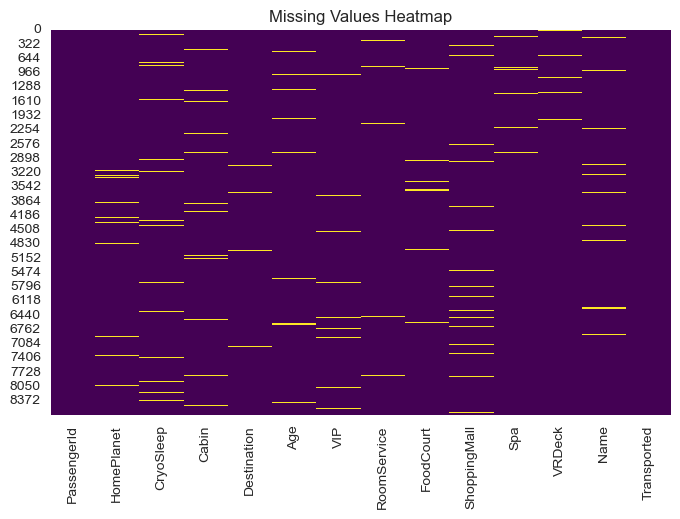

In [5]:
plt.figure(figsize=(8,5))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()


## 3. Feature Engineering

### 3.1 Extracting Info from `Cabin` and `PassengerId`

The `Cabin` column is in the format `deck/num/side`, and `PassengerId` contains the group number. We extract this information.

In [6]:
df['deck'] = df.Cabin.str.extract(r'^(.)')
df['num'] = df.Cabin.str.extract(r'(\d+)')
df['side'] = df.Cabin.str.split('/').str[2]
df['groupId'] = df.PassengerId.str.extract(r'(\d\d\d\d)')
df['Passenger_Id'] = df.PassengerId.str.extract(r'(\d{2}$)')

df = df.drop('Cabin', axis=1)
df = df.drop('PassengerId', axis=1)

df[['deck', 'num', 'side', 'groupId']].head()


,deck,num,side,groupId
0,B,0,P,0001
1,F,0,S,0002
2,A,0,S,0003
3,A,0,S,0003
4,F,1,S,0004


### 3.2 Building the `spending` Feature (Total Cost)

In [7]:
cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
df['spending'] = df[cols].fillna(0).sum(axis=1)

df = df.drop(['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck'], axis=1)

df['spending'].describe()


count     8693.000000
mean      1440.866329
std       2803.045694
min          0.000000
25%          0.000000
50%        716.000000
75%       1441.000000
max      35987.000000
Name: spending, dtype: float64

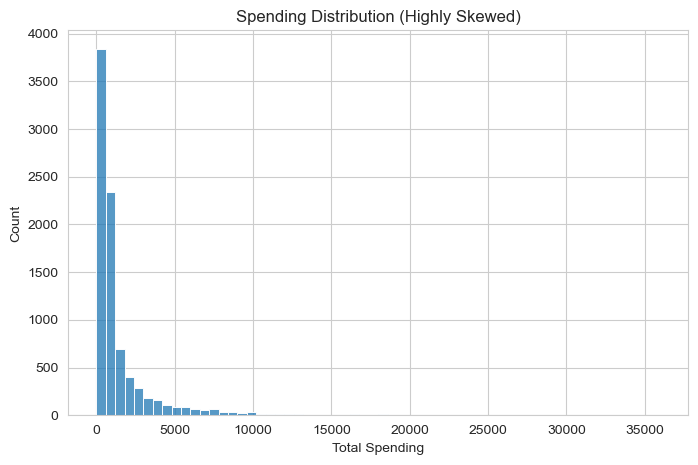

In [8]:
plt.figure(figsize=(8,5))
sns.histplot(df['spending'], bins=60)
plt.title("Spending Distribution (Highly Skewed)")
plt.xlabel("Total Spending")
plt.show()


📌 The `spending` distribution is heavily right-skewed; that's why a `log1p` transformation is used on this column later.

### 3.3 Identifying Families

In [9]:
df['Surname'] = df['Name'].str.split().str[-1]
df['family'] = df.groupby(['groupId', 'Surname']).ngroup()

print("Number of unique families:", df['family'].nunique())


Number of unique families: 6387


In [10]:
mask = (df['CryoSleep'] == True)
df.loc[mask, ['spending']] = df.loc[mask, ['spending']].fillna(0)


## 4. Exploratory Data Analysis & Pattern-Based Imputation

In this section, patterns discovered through EDA are used to fill in missing values. Each section includes a chart showing the pattern used.

### 4.1 `HomePlanet` Based on Group and the VIP/CryoSleep Condition

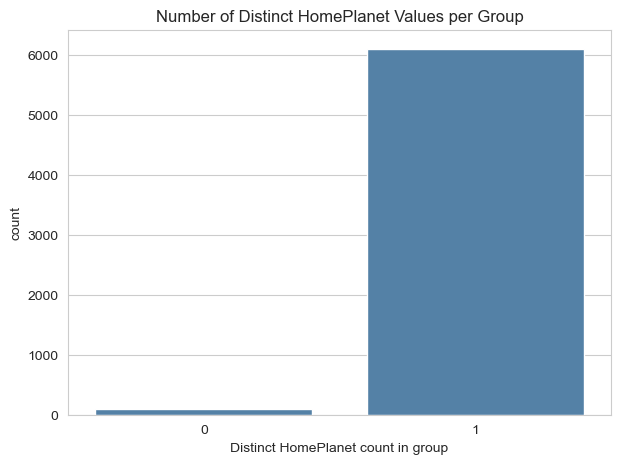

In [11]:
group_hp_purity = df.groupby('groupId')['HomePlanet'].nunique()

plt.figure(figsize=(7,5))
sns.countplot(x=group_hp_purity, color="steelblue")
plt.title("Number of Distinct HomePlanet Values per Group")
plt.xlabel("Distinct HomePlanet count in group")
plt.show()


📌 Data exploration reveals a strong relationship between **HomePlanet** and **groupId**. Members of the same group almost always originate from the same **HomePlanet**, meaning each group typically has only one **HomePlanet** value. Therefore, missing values are first imputed using the mode of each passenger group.


In [12]:
def fill_mode(x):
    m = x.mode()
    return m.iloc[0] if not m.empty else None

df['HomePlanet'] = df['HomePlanet'].fillna(
    df.groupby('groupId')['HomePlanet'].transform(fill_mode)
)


In [13]:
mask_vip_cryo = (df['VIP'] == True) & (df['CryoSleep'] == True)
df.loc[mask_vip_cryo, 'HomePlanet'].value_counts(dropna=False)


HomePlanet
Europa    20
NaN        1
Name: count, dtype: int64

📌 Exploratory data analysis (EDA) shows that almost all passengers with both **CryoSleep = True** and **VIP = True** have **HomePlanet = 'Europa'** (20 out of 21 observed cases). This strong pattern is therefore used to impute missing **HomePlanet** values when both conditions are satisfied.


In [ ]:
maskn = (df['VIP'] == True) & (df['CryoSleep'] == True)
df.loc[maskn, 'HomePlanet'] = df.loc[maskn, 'HomePlanet'].fillna('Europa')


📌 After applying the previous imputation rules, only **110** missing **HomePlanet** values remained. No meaningful pattern was found among these records. Further analysis showed that **Age** had no significant relationship with **HomePlanet**, except for passengers aged **0–12**. Since all remaining missing records belonged to passengers older than **18**, the remaining **HomePlanet** values were imputed using the overall mode of the dataset.



In [ ]:

df['HomePlanet'] = df['HomePlanet'].fillna(df['HomePlanet'].mode()[0])

df['Destination'] = (
    df.groupby('HomePlanet')['Destination']
      .transform(lambda x: x.fillna(x.mode().iloc[0]))
)

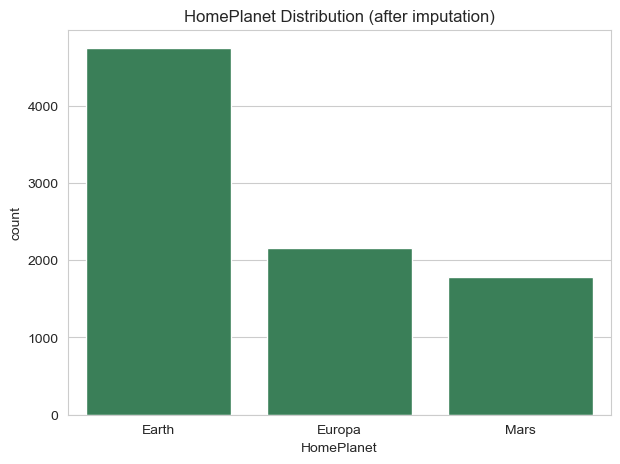

In [15]:
plt.figure(figsize=(7,5))
sns.countplot(data=df, x='HomePlanet', order=df['HomePlanet'].value_counts().index, color="seagreen")
plt.title("HomePlanet Distribution (after imputation)")
plt.show()


### 4.2 `CryoSleep` Based on Its Relationship with `spending`

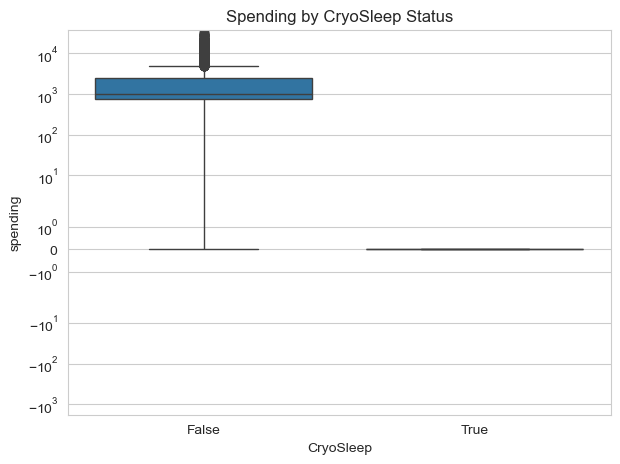

In [16]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x='CryoSleep', y='spending')
plt.yscale("symlog")
plt.title("Spending by CryoSleep Status")
plt.show()


📌 No passenger with `spending > 0` was ever in `CryoSleep=True` (makes sense; someone in cryosleep can't make purchases). Therefore:
- When `spending > 0`: missing `CryoSleep` is filled with `False`
- When `spending == 0`: about 85% of passengers were `CryoSleep=True`, so it's filled with `True`

⚠️ Note: although about 82% of passengers with `CryoSleep=True` ended up `Transported` (a strong pattern), the target variable was intentionally not used for imputation, to avoid **target leakage**.

In [17]:
maskm = (df['spending'] > 0)
df.loc[maskm, 'CryoSleep'] = df.loc[maskm, 'CryoSleep'].fillna(False)

msk = (df['CryoSleep'].isna()) & (df['spending'] == 0)
df.loc[msk, 'CryoSleep'] = df.loc[msk, 'CryoSleep'].fillna(True)


C:\Users\DATA\AppData\Local\Temp\ipykernel_11460\2096940025.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.loc[maskm, 'CryoSleep'] = df.loc[maskm, 'CryoSleep'].fillna(False)
C:\Users\DATA\AppData\Local\Temp\ipykernel_11460\2096940025.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.loc[msk, 'CryoSleep'] = df.loc[msk, 'CryoSleep'].fillna(True)


### 4.3 `side` and `num` (Based on Group Membership)

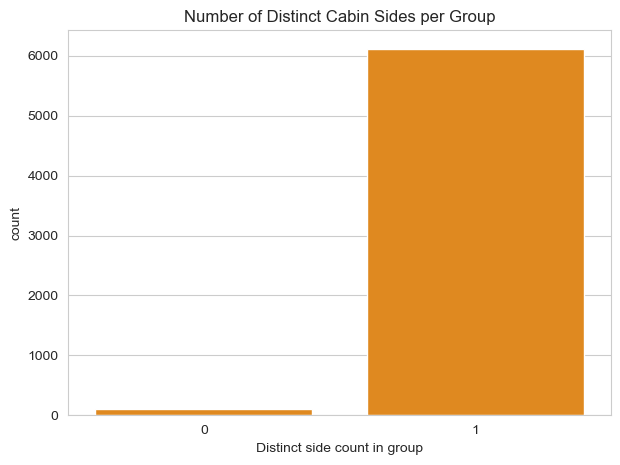

In [18]:
group_side_purity = df.groupby('groupId')['side'].nunique(dropna=True)

plt.figure(figsize=(7,5))
sns.countplot(x=group_side_purity, color="darkorange")
plt.title("Number of Distinct Cabin Sides per Group")
plt.xlabel("Distinct side count in group")
plt.show()


📌 Members of a group almost always have the same cabin side (`side`). Therefore, missing values are filled with the within-group mode.

In [19]:
df['side'] = df.groupby('groupId')['side'].transform(
    lambda x: x.fillna(x.mode()[0]) if not x.mode().empty else x
)

df['num'] = df.groupby('groupId')['num'].transform(
    lambda x: x.fillna(x.mode()[0]) if not x.mode().empty else x
)
df['num'] = df['num'].fillna(df['num'].mode()[0])


### 4.4 `deck` Based on `HomePlanet` and `CryoSleep`

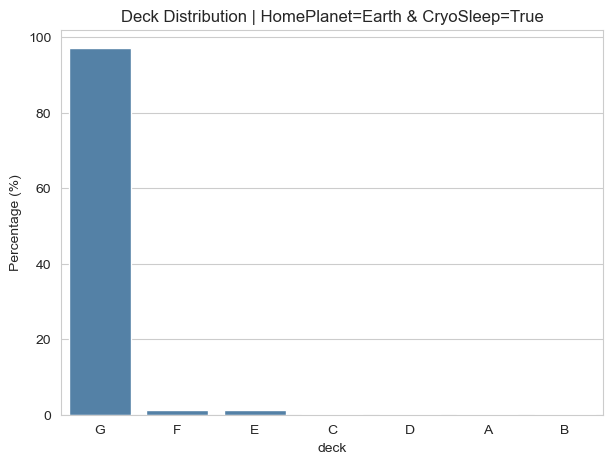

In [20]:
tmp_earth_cryo = df[(df['HomePlanet'] == 'Earth') & (df['CryoSleep'] == True)]
deck_dist = tmp_earth_cryo['deck'].value_counts(normalize=True) * 100

plt.figure(figsize=(7,5))
sns.barplot(x=deck_dist.index, y=deck_dist.values, color="steelblue")
plt.title("Deck Distribution | HomePlanet=Earth & CryoSleep=True")
plt.ylabel("Percentage (%)")
plt.show()


📌 About 97% of passengers with `HomePlanet=Earth` and `CryoSleep=True` were on `deck = G`. A similar pattern was found for young `Mars` passengers with `deck=F`.

In [21]:
msk_deck = (df['HomePlanet'] == 'Earth') & (df['CryoSleep'] == True)
df.loc[msk_deck, 'deck'] = df.loc[msk_deck, 'deck'].fillna('G')

msk_deck2 = (
    (df['HomePlanet'] == 'Mars') &
    (df['CryoSleep'] == True) &
    (df['Age'] <= 20)
)
df.loc[msk_deck2, 'deck'] = df.loc[msk_deck2, 'deck'].fillna('F')


### 4.5 `spending` for Children

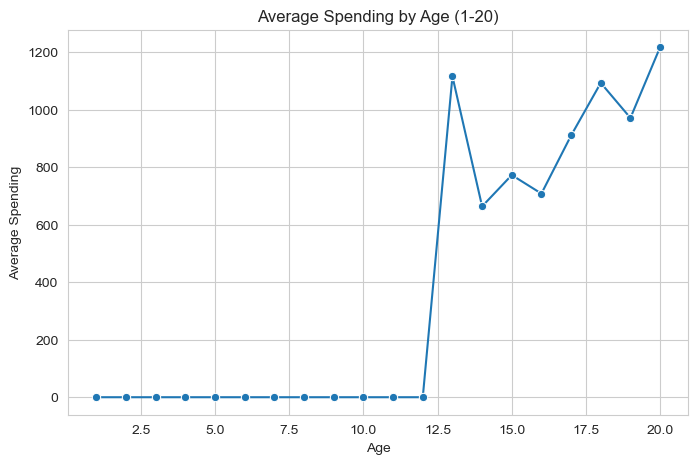

In [22]:
age_spending = df[df['Age'].between(1, 20)].groupby('Age')['spending'].mean()

plt.figure(figsize=(8,5))
sns.lineplot(x=age_spending.index, y=age_spending.values, marker="o")
plt.title("Average Spending by Age (1-20)")
plt.xlabel("Age")
plt.ylabel("Average Spending")
plt.show()


📌 Passengers aged 12 or younger had no spending at all; therefore, `spending` for this age group is set to zero.

In [23]:
msk_spending = (df['Age'] <= 12)
df.loc[msk_spending, 'spending'] = 0


### 4.6 `VIP` for Young Passengers

In [24]:
tmp_young = df[(df['Age'] <= 20) & (df['VIP'].notna())]
vip_rate = tmp_young['VIP'].value_counts(normalize=True) * 100
vip_rate


VIP
False    99.873524
True      0.126476
Name: proportion, dtype: float64

📌 Almost no passenger under 20 was VIP; therefore, the missing `VIP` value for this age group is filled with `False`.

In [25]:
msk_vip = (df['Age'] <= 20)
df.loc[msk_vip, 'VIP'] = df.loc[msk_vip, 'VIP'].fillna(False)


C:\Users\DATA\AppData\Local\Temp\ipykernel_11460\747906830.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.loc[msk_vip, 'VIP'] = df.loc[msk_vip, 'VIP'].fillna(False)


### 4.7 `Destination` Based on `HomePlanet` and `VIP`

In [26]:
tmp_mars = df[(df['HomePlanet'] == 'Mars') & (df['VIP'] == False) & (df['Destination'].notna())]
dest_dist = tmp_mars['Destination'].value_counts(normalize=True) * 100
dest_dist


Destination
TRAPPIST-1e      86.288416
55 Cancri e      11.347518
PSO J318.5-22     2.364066
Name: proportion, dtype: float64

📌 Over 85% of `Mars` passengers with `VIP=False` had `TRAPPIST-1e` as their destination.

In [27]:
msk_des = (df['HomePlanet'] == 'Mars') & (df['VIP'] == False)
df.loc[msk_des, 'Destination'] = df.loc[msk_des, 'Destination'].fillna('TRAPPIST-1e')


### 4.8 `Age` for Children in Multi-Member Families

In [28]:
family_size = df.groupby('family')['family'].transform('size')

tmp_child_pattern = df[
    (family_size > 1) &
    (df['Age'].notna()) &
    (df['VIP'] == False) &
    (df['CryoSleep'] == False) &
    (df['spending'] == 0)
]

print(f"Count: {len(tmp_child_pattern)}")
print(f"Child (Age <= 12) rate: {(tmp_child_pattern['Age'] <= 12).mean() * 100:.2f}%")


Count: 368
Child (Age <= 12) rate: 90.22%


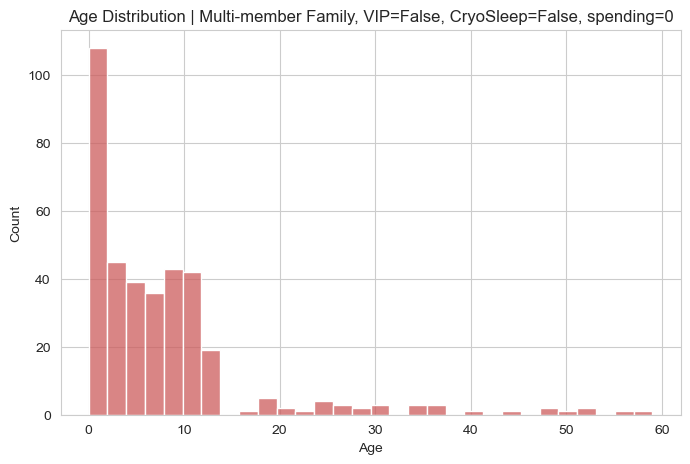

In [29]:
plt.figure(figsize=(8,5))
sns.histplot(tmp_child_pattern['Age'], bins=30, color="indianred")
plt.title("Age Distribution | Multi-member Family, VIP=False, CryoSleep=False, spending=0")
plt.show()


📌 In multi-member families, passengers with `VIP=False`, `CryoSleep=False`, and `spending=0` were children (age ≤ 12) in about 90% of cases. Missing `Age` values matching this pattern are set to 6.

In [30]:
msk_age = (
    (family_size > 1) &
    df['Age'].isna() &
    (df['VIP'] == False) &
    (df['CryoSleep'] == False) &
    (df['spending'] == 0)
)
df.loc[msk_age, 'Age'] = 6


### 4.9 Within-Family Imputation (VIP, deck, Age, Destination)

Members of a family share the same value for these features in over 85% of cases, so the within-family mode/median is used.

In [31]:
def fill_vip(group):
    known = group.dropna()
    if len(known) == 0:
        return group
    return group.fillna(known.mode()[0])

mask_ = df['family'].notna()
df.loc[mask_, 'VIP'] = df.loc[mask_].groupby('family')['VIP'].transform(fill_vip)


def fill_deck(group):
    known = group.dropna()
    if len(known) == 0:
        return group
    return group.fillna(known.mode()[0])

mask_ = df['family'].notna()
df.loc[mask_, 'deck'] = df.loc[mask_].groupby('family')['deck'].transform(fill_deck)


def fill_Age(group):
    known = group.dropna()
    if len(known) == 0:
        return group
    return group.fillna(known.median())

mask_ = df['family'].notna()
df.loc[mask_, 'Age'] = df.loc[mask_].groupby('family')['Age'].transform(fill_Age)


def fill_Destination(group):
    known = group.dropna()
    if len(known) == 0:
        return group
    return group.fillna(known.mode()[0])

mask_ = df['family'].notna()
df.loc[mask_, 'Destination'] = df.loc[mask_].groupby('family')['Destination'].transform(fill_Destination)


C:\Users\DATA\AppData\Local\Temp\ipykernel_11460\4213081090.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return group.fillna(known.mode()[0])


### 4.10 Filling the Remaining `VIP`

In [32]:
df['VIP'].value_counts(normalize=True) * 100


VIP
False    97.685777
True      2.314223
Name: proportion, dtype: float64

📌 97.69% of passengers are not VIP, and no specific pattern was found for the remaining missing values; therefore, they're filled with `False`.

In [33]:
df['VIP'] = df['VIP'].fillna(False)


C:\Users\DATA\AppData\Local\Temp\ipykernel_11460\3310573808.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['VIP'] = df['VIP'].fillna(False)


### 4.11 `Age` Based on the Earth Pattern and Group Median

In [34]:
tmp_earth_pattern = df[
    (df['HomePlanet'] == 'Earth') &
    (df['VIP'] == False) &
    (df['CryoSleep'] == False) &
    (df['spending'] == 0) &
    (df['Age'] <= 12)
]
tmp_earth_pattern['Age'].describe()


count    291.000000
mean       5.326460
std        4.151438
min        0.000000
25%        1.000000
50%        6.000000
75%        9.000000
max       12.000000
Name: Age, dtype: float64

📌 Exploratory data analysis (EDA) shows that all **291** passengers matching the following pattern:

* **HomePlanet = 'Earth'**
* **VIP = False**
* **CryoSleep = False**
* **Total spending = 0**

were between **0 and 12 years old**. Since the median age within this group is **6**, missing **Age** values for passengers matching this pattern are imputed with **6**.


In [35]:
msk__age = (
    df['Age'].isna() &
    (df['HomePlanet'] == 'Earth') &
    (df['VIP'] == False) &
    (df['CryoSleep'] == False) &
    (df['spending'] == 0)
)
df.loc[msk__age, 'Age'] = 6


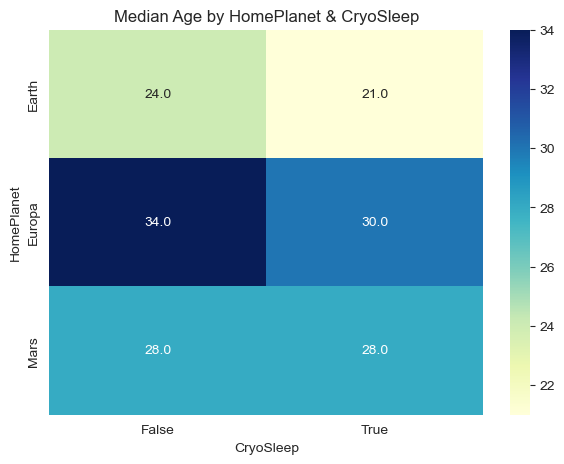

In [36]:
age_by_group = df.groupby(['HomePlanet', 'CryoSleep'])['Age'].median().unstack()

plt.figure(figsize=(7,5))
sns.heatmap(age_by_group, annot=True, cmap="YlGnBu", fmt=".1f")
plt.title("Median Age by HomePlanet & CryoSleep")
plt.show()


📌 Exploratory data analysis (EDA) shows that the median **Age** varies across different **(HomePlanet, CryoSleep)** groups, ranging from **21 to 34 years**. Therefore, the remaining missing **Age** values are imputed using the median age of the corresponding **(HomePlanet, CryoSleep)** group rather than the global median.


In [37]:
df['Age'] = df['Age'].fillna(
    df.groupby(['HomePlanet', 'CryoSleep'])['Age'].transform('median')
)


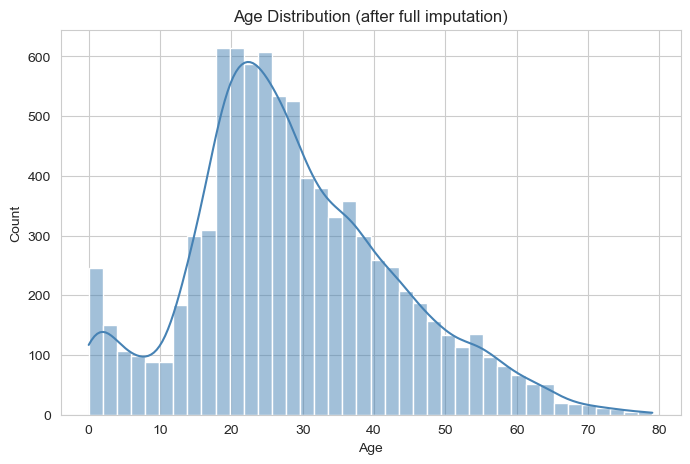

In [38]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=40, kde=True, color="steelblue")
plt.title("Age Distribution (after full imputation)")
plt.show()


### 4.12 Remaining `side` and `deck`

In [ ]:
df['side'] = df['side'].fillna(df['side'].mode()[0])

#? Based on EDA, HomePlanet and CryoSleep provide the best available
#? grouping for estimating missing Deck values. Although the strength
#? of the pattern varies across groups, using the mode within each
#? (HomePlanet, CryoSleep) group provides a more informative estimate
#? than using the global mode of the entire dataset.

def fill_deck(group):
    m = group.mode()
    return group.fillna(m.iloc[0]) if not m.empty else group

df['deck'] = df.groupby(['HomePlanet', 'CryoSleep'])['deck'].transform(fill_deck)


### 4.13 Remaining `Destination` Based on `HomePlanet`

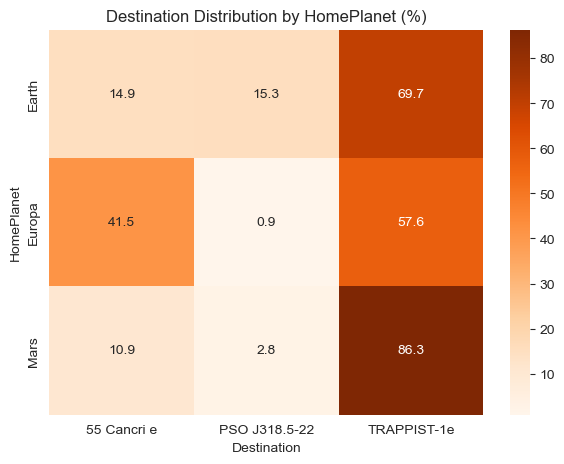

In [40]:
dest_by_planet = pd.crosstab(df['HomePlanet'], df['Destination'], normalize='index') * 100

plt.figure(figsize=(7,5))
sns.heatmap(dest_by_planet, annot=True, cmap="Oranges", fmt=".1f")
plt.title("Destination Distribution by HomePlanet (%)")
plt.show()


📌 Exploratory data analysis (EDA) shows that each **HomePlanet** has a dominant **Destination**. Therefore, the remaining missing **Destination** values are imputed using the mode of the corresponding **HomePlanet**, providing a more accurate estimate than relying on the global mode of the dataset.


In [41]:
df['Destination'] = (
    df.groupby('HomePlanet')['Destination']
      .transform(lambda x: x.fillna(x.mode()[0]))
)


### 4.14 Final Cleanup and Missing-Value Check

In [42]:
df['Surname'] = df['Surname'].fillna('Unknown')
df['family'] = df['family'].fillna(-1)

df.isnull().sum().sort_values(ascending=False).head(10)


Name           200
HomePlanet       0
CryoSleep        0
Destination      0
Age              0
VIP              0
Transported      0
deck             0
num              0
side             0
dtype: int64

📌 After this stage, essentially all missing values important for modeling have been filled.

## 5. Final Feature Construction

In [43]:
skewness_check = df[['spending', 'Age']].skew()
skewness_check


spending    4.417588
Age         0.428229
dtype: float64

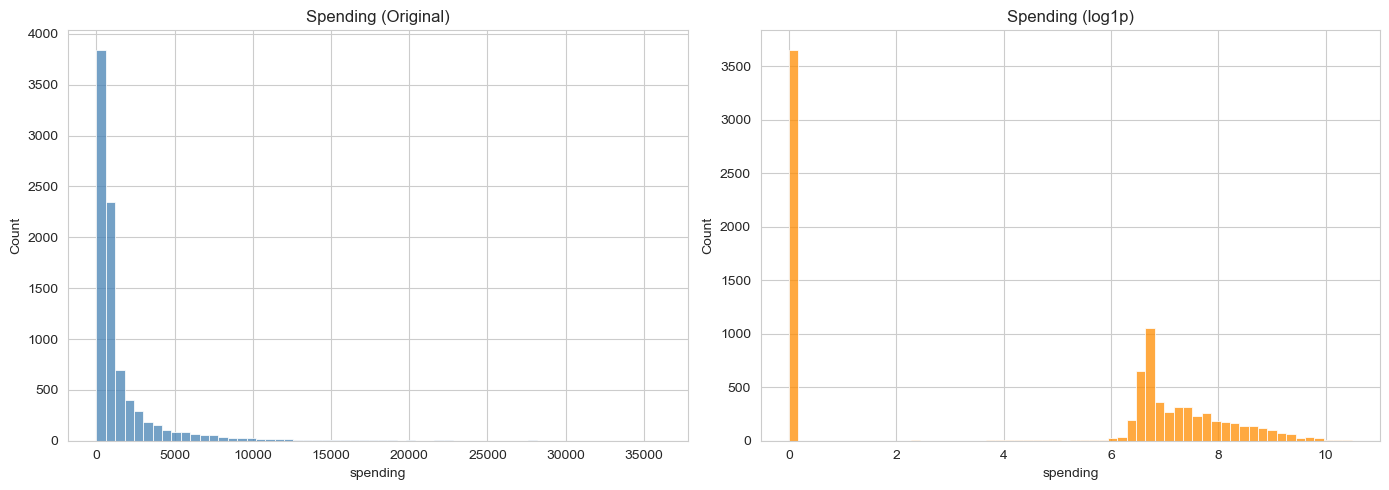

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['spending'], bins=60, ax=axes[0], color="steelblue")
axes[0].set_title("Spending (Original)")

sns.histplot(np.log1p(df['spending']), bins=60, ax=axes[1], color="darkorange")
axes[1].set_title("Spending (log1p)")

plt.tight_layout()
plt.show()


📌 Due to the severe skewness of `spending`, a `log1p` transform is used to improve model performance.

In [45]:
df['log_spending'] = np.log1p(df['spending'])
df['is_child'] = (df['Age'] <= 12).astype(int)
df["group_size"] = df.groupby("groupId")["groupId"].transform("size")


### 5.1 Relationship Between Engineered Features and the Target

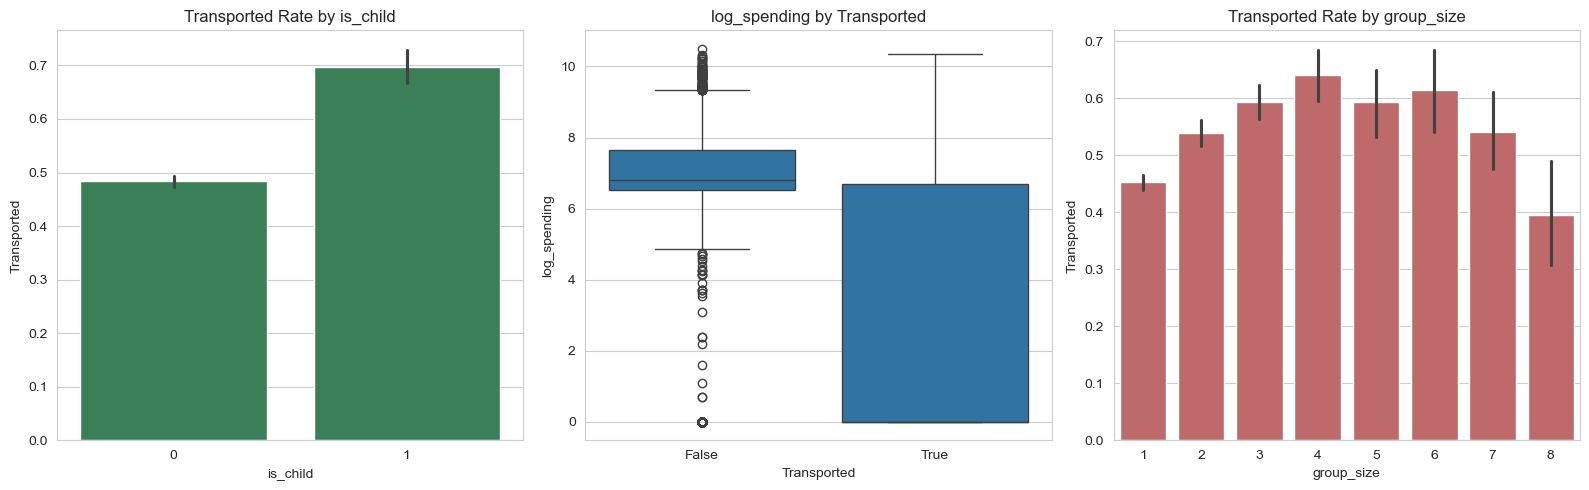

In [46]:
fig, axes = plt.subplots(1, 3, figsize=(16,5))

sns.barplot(data=df, x='is_child', y=df['Transported'].astype(int), ax=axes[0], color="seagreen")
axes[0].set_title("Transported Rate by is_child")

sns.boxplot(data=df, x='Transported', y='log_spending', ax=axes[1])
axes[1].set_title("log_spending by Transported")

sns.barplot(data=df, x='group_size', y=df['Transported'].astype(int), ax=axes[2], color="indianred")
axes[2].set_title("Transported Rate by group_size")

plt.tight_layout()
plt.show()


📌 Children (`is_child=1`) and passengers with lower `log_spending` have a higher Transported rate — this is consistent with the known relationship between `CryoSleep` and `Transported`.

## 6. Train / Test Split

In [47]:
x = df[['HomePlanet', 'CryoSleep', 'Destination', 'Age', 'is_child', 'VIP',
       'deck', 'num', 'side', 'groupId', 'log_spending', 'family']]

y = df['Transported']

cat_feature = ['HomePlanet', 'Destination', 'deck', 'side']

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_feature)
    ],
    remainder="passthrough"
)

train_x, test_x, train_y, test_y = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", train_x.shape)
print("Test shape :", test_x.shape)


Train shape: (6954, 12)
Test shape : (1739, 12)


📌 Categorical feature preprocessing is done inside a `ColumnTransformer`, within the Pipeline itself (not manually on the dataframe), so the raw data stays untouched and the same transforms can be applied to new data (e.g. `test.csv`).

## 7. Helper Function for GridSearchCV

In [48]:
def mp_finder(model, parameters):
    grid = GridSearchCV(
        estimator=model,
        param_grid=parameters,
        cv=5,
        scoring='accuracy',
        n_jobs=-1,
        refit=True,
        verbose=2,
    )
    grid.fit(train_x, train_y)

    train_pred = grid.predict(train_x)
    test_pred = grid.predict(test_x)

    train_acc = accuracy_score(train_y, train_pred)
    test_acc = accuracy_score(test_y, test_pred)

    print(f"Best Params: {grid.best_params_}")
    print("-" * 40)
    print(f"Train Accuracy : {train_acc:.4f}")
    print(f"Test Accuracy  : {test_acc:.4f}")
    print(f"Gap            : {train_acc - test_acc:.4f}")

    return train_acc, test_acc


## 8. Base Models (Pipelines)

Four base models with the best parameters found by `GridSearchCV` (the search itself is time-consuming and kept commented out) are defined.

### 8.1 CatBoost

In [ ]:
# Best Score : 0.7598510465531241
# Best Params : {'depth': 4, 'iterations': 500, 'l2_leaf_reg': 3, 'learning_rate': 0.03, 'subsample': 0.8}
# Train Accuracy : 0.7754
# Test Accuracy  : 0.7602
# Gap            : 0.0152
# ?Experiments showed no meaningful difference between CatBoost with and without One-Hot Encoding;
# ?however, to keep consistency with the Stacking framework, a Pipeline with OneHotEncoder was used.

pipe_cat = Pipeline([
    ("preprocess", preprocessor),
    ("model", CatBoostClassifier(
        depth=4, iterations=500, l2_leaf_reg=3, learning_rate=0.03, subsample=0.8, verbose=0
    ))
])


### 8.2 XGBoost

In [50]:
# xg_param_grid = {
#     "n_estimators": [300, 500, 700],
#     "max_depth": [4, 5, 6],
#     "learning_rate": [0.03, 0.05, 0.1],
#     "subsample": [0.8, 1.0],
#     "colsample_bytree": [0.8, 1.0],
#     "min_child_weight": [1, 3],
#     "gamma": [0, 0.1],
#     "reg_alpha": [0, 0.1],
#     "reg_lambda": [1, 3]
# }

pipe_xg = Pipeline([
    ("preprocess", preprocessor),
    ("model", XGBClassifier(
        colsample_bytree=0.8, gamma=0, learning_rate=0.03, max_depth=4,
        min_child_weight=3, n_estimators=300, reg_alpha=0, reg_lambda=3, subsample=0.8
    ))
])
# xg_train_acc, xg_test_acc = mp_finder(pipe_xg, xg_param_grid)

# Best Params: {'model__colsample_bytree': 0.8, 'model__gamma': 0, 'model__learning_rate': 0.03,
#               'model__max_depth': 4, 'model__min_child_weight': 3, 'model__n_estimators': 300,
#               'model__reg_alpha': 0, 'model__reg_lambda': 3, 'model__subsample': 0.8}
# ----------------------------------------
# Train Accuracy : 0.7804
# Test Accuracy  : 0.7602
# Gap            : 0.0202


### 8.3 Random Forest

In [51]:
# rf_param_grid = {
#     "model__n_estimators": [200, 500, 800],
#     "model__max_depth": [None, 10, 20, 30],
#     "model__min_samples_split": [2, 5, 10],
#     "model__min_samples_leaf": [1, 2, 4],
#     "model__max_features": ["sqrt", "log2"],
#     "model__bootstrap": [True, False]
# }

pipe_rf = Pipeline([
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier())
])
# rf_train_acc, rf_test_acc = mp_finder(pipe_rf, rf_param_grid)

# Best Params: {'model__bootstrap': False, 'model__max_depth': 10, 'model__max_features': 'sqrt',
#               'model__min_samples_leaf': 1, 'model__min_samples_split': 10, 'model__n_estimators': 200}
# ----------------------------------------
# Train Accuracy : 0.8284
# Test Accuracy  : 0.7614
# Gap            : 0.0671


### 8.4 LightGBM

In [52]:
# lgbm_param_grid = {
#     "model__n_estimators": [300, 500],
#     "model__learning_rate": [0.03, 0.05],
#     "model__max_depth": [-1, 6],
#     "model__num_leaves": [31, 63],
#     "model__min_child_samples": [20, 40],
#     "model__subsample": [0.8, 1.0],
#     "model__colsample_bytree": [0.8, 1.0]
# }

pipe_lg = Pipeline([
    ("preprocess", preprocessor),
    ("model", LGBMClassifier(
        colsample_bytree=0.8, learning_rate=0.03, max_depth=6,
        min_child_samples=40, n_estimators=500, num_leaves=31, subsample=0.8
    ))
])
# lg_train_acc, lg_test_acc = mp_finder(pipe_lg, lgbm_param_grid)

# Best Params: {'model__colsample_bytree': 0.8, 'model__learning_rate': 0.03, 'model__max_depth': 6,
#               'model__min_child_samples': 40, 'model__n_estimators': 500, 'model__num_leaves': 31,
#               'model__subsample': 0.8}
# ----------------------------------------
# Train Accuracy : 0.8259
# Test Accuracy  : 0.7631
# Gap            : 0.0628


### 8.5 Visual Comparison of Base Models

In [53]:
base_results = pd.DataFrame({
    "Model": ["CatBoost", "XGBoost", "Random Forest", "LightGBM"],
    "Train_Accuracy": [0.7754, 0.7804, 0.8284, 0.8259],
    "Test_Accuracy":  [0.7602, 0.7602, 0.7614, 0.7631],
})
base_results["Gap"] = base_results["Train_Accuracy"] - base_results["Test_Accuracy"]
base_results


,Model,Train_Accuracy,Test_Accuracy,Gap
0,CatBoost,0.7754,0.7602,0.0152
1,XGBoost,0.7804,0.7602,0.0202
2,Random Forest,0.8284,0.7614,0.0670
3,LightGBM,0.8259,0.7631,0.0628


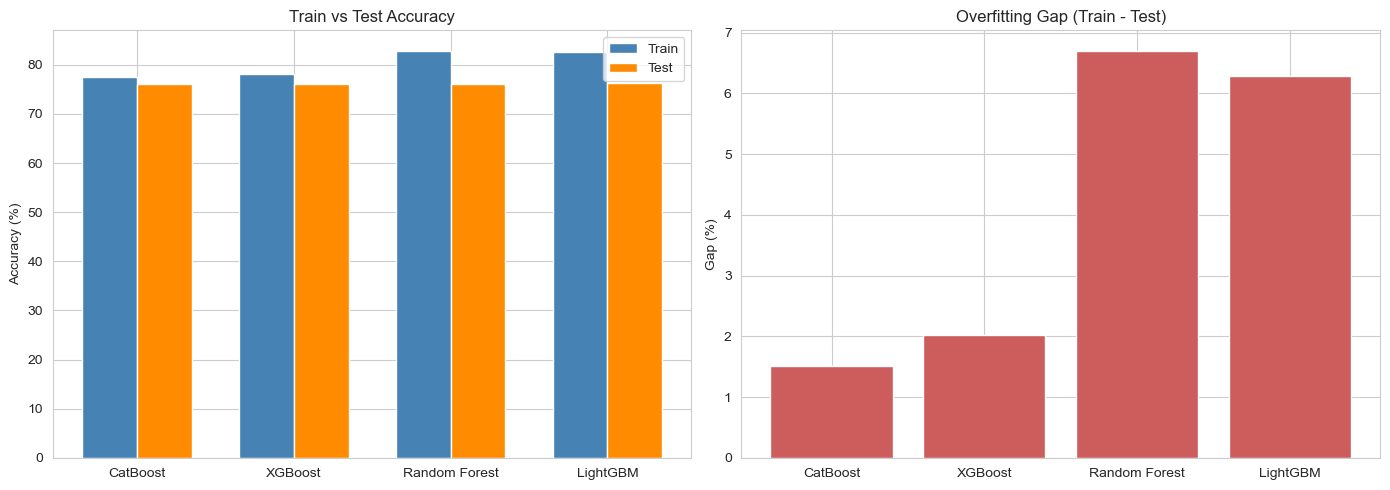

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

x_pos = np.arange(len(base_results))
width = 0.35

axes[0].bar(x_pos - width/2, base_results["Train_Accuracy"]*100, width, label="Train", color="steelblue")
axes[0].bar(x_pos + width/2, base_results["Test_Accuracy"]*100, width, label="Test", color="darkorange")
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(base_results["Model"])
axes[0].set_ylabel("Accuracy (%)")
axes[0].set_title("Train vs Test Accuracy")
axes[0].legend()

axes[1].bar(base_results["Model"], base_results["Gap"]*100, color="indianred")
axes[1].set_ylabel("Gap (%)")
axes[1].set_title("Overfitting Gap (Train - Test)")

plt.tight_layout()
plt.show()


📌 CatBoost and XGBoost have the smallest train/test gap (least overfitting), while Random Forest and LightGBM have higher train accuracy but a larger gap. This diversity makes combining these models in a Stacking ensemble reasonable.

## 9. Stacking Ensemble

In [55]:
estimators = [
    ("cat", pipe_cat),
    ("xgb", pipe_xg),
    ("lgb", pipe_lg),
]

meta_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=4,
    random_state=42
)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

stack = StackingClassifier(
    estimators=estimators,
    final_estimator=meta_model,
    cv=cv,
    stack_method="predict_proba",
    passthrough=False,
    n_jobs=-1
)

stack.fit(train_x, train_y)


StackingClassifier(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimators=[('cat',
                                Pipeline(steps=[('preprocess',
                                                 ColumnTransformer(remainder='passthrough',
                                                                   transformers=[('cat',
                                                                                  OneHotEncoder(handle_unknown='ignore'),
                                                                                  ['HomePlanet',
                                                                                   'Destination',
                                                                                   'deck',
                                                                                   'side'])])),
                                                ('model',
                                                 CatBoostClassifier(depth=4, iterations=500, l2_leaf_reg=3, learning...
                                                                   transformers=[('cat',
                                                                                  OneHotEncoder(handle_unknown='ignore'),
                                                                                  ['HomePlanet',
                                                                                   'Destination',
                                                                                   'deck',
                                                                                   'side'])])),
                                                ('model',
                                                 LGBMClassifier(colsample_bytree=0.8,
                                                                learning_rate=0.03,
                                                                max_depth=6,
                                                                min_child_samples=40,
                                                                n_estimators=500,
                                                                subsample=0.8))]))],
                   final_estimator=RandomForestClassifier(max_depth=4,
                                                          n_estimators=200,
                                                          random_state=42),
                   n_jobs=-1, stack_method='predict_proba')

In [56]:
train_pred = stack.predict(train_x)
test_pred = stack.predict(test_x)

train_acc = accuracy_score(train_y, train_pred)
test_acc = accuracy_score(test_y, test_pred)

print("Train :", train_acc)
print("Test  :", test_acc)
print("Gap   :", train_acc - test_acc)

# Experimented results for the meta-model:
# Train : 0.7911993097497843
# Test  : 0.765382403680276
# Gap   : 0.02581690606950826
# Best meta-model found: Random Forest


Train : 0.7911993097497843
Test  : 0.765382403680276
Gap   : 0.02581690606950826


### 9.1 Final Comparison: Base Models vs Stacking

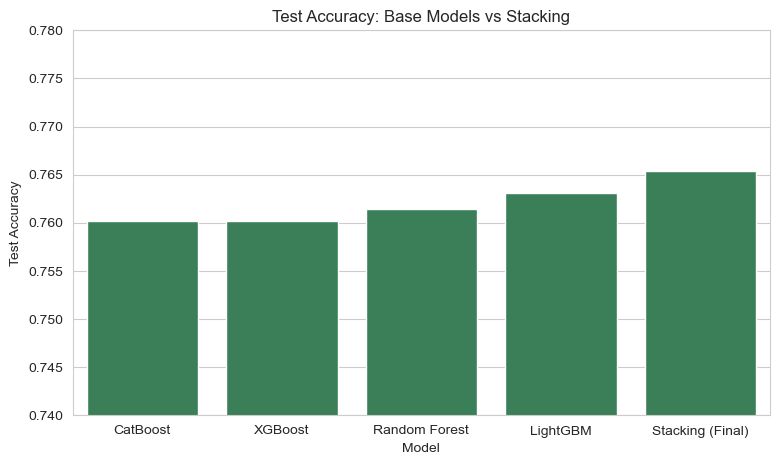

In [57]:
final_comparison = pd.concat([
    base_results[["Model", "Train_Accuracy", "Test_Accuracy"]],
    pd.DataFrame({
        "Model": ["Stacking (Final)"],
        "Train_Accuracy": [train_acc],
        "Test_Accuracy": [test_acc],
    })
], ignore_index=True)

plt.figure(figsize=(9,5))
sns.barplot(data=final_comparison, x="Model", y="Test_Accuracy", color="seagreen")
plt.title("Test Accuracy: Base Models vs Stacking")
plt.ylabel("Test Accuracy")
plt.ylim(0.74, 0.78)
plt.show()


📌 The Stacking model performs slightly better than or similar to the best base model (LightGBM at 76.31%) on the test set, but since it learns from the output of multiple models, it's expected to generalize more reliably on real data.

## 10. Final Evaluation: Cross Validation

In [58]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    estimator=stack,
    X=x,
    y=y,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

print("=" * 40)
print("Stacking Cross Validation")
print("=" * 40)
print(f"Fold Scores : {scores}")
print(f"Mean Accuracy : {scores.mean():.4f}")
print(f"Std Accuracy  : {scores.std():.4f}")
print(f"95% CI : {scores.mean():.4f} ± {1.96 * scores.std():.4f}")


Stacking Cross Validation
Fold Scores : [0.76365727 0.76078206 0.7653824  0.76064442 0.76237054]
Mean Accuracy : 0.7626
Std Accuracy  : 0.0018
95% CI : 0.7626 ± 0.0035


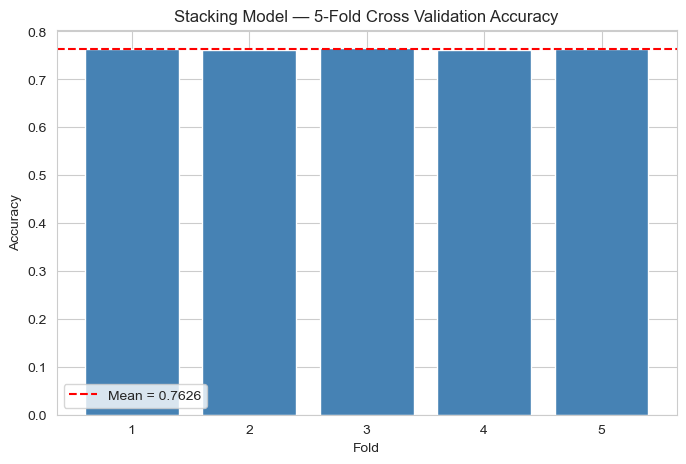

In [59]:
plt.figure(figsize=(8,5))
plt.bar(range(1, len(scores)+1), scores, color="steelblue")
plt.axhline(scores.mean(), color="red", linestyle="--", label=f"Mean = {scores.mean():.4f}")
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.title("Stacking Model — 5-Fold Cross Validation Accuracy")
plt.legend()
plt.show()


📌 The low spread across folds (low Std) shows the model's performance is stable across different parts of the data and isn't dependent on one specific train/test split.

## 11. Summary

- Best base model: **LightGBM** with Test Accuracy ≈ 76.31%
- Final model: **Stacking** (CatBoost + XGBoost + LightGBM → Random Forest) with Test Accuracy ≈ 76.54% and stable mean accuracy in Cross Validation
- Key project decisions:
  - Imputation based on patterns actually found in the data (not simple global mean/mode)
  - Deliberate avoidance of target leakage during imputation
  - Used `log1p` for `spending` due to severe skewness
  - Preprocessing via `Pipeline` + `ColumnTransformer` instead of directly mutating the dataframe
  - Combined multiple models with `StackingClassifier` for better generalization

# Conclusion

This project demonstrates an end-to-end machine learning workflow for the Spaceship Titanic dataset.

Key techniques used include:

- EDA-driven missing value imputation
- Feature engineering
- Pipeline-based preprocessing
- Hyperparameter tuning with GridSearchCV
- Ensemble learning with StackingClassifier
- 5-Fold Stratified Cross Validation

Final Cross Validation Accuracy:

76.26%